### ***Unsupervised ML***
  - ***Unsupervised Learning is a Machine Learning technique where the model learns patterns from unlabeled data. Since there is no target/output column, the algorithm tries to discover hidden structures, groups, relationships, or patterns in the dataset.***

---

- ***Clustering***
  - ***Clustering is an Unsupervised Machine Learning technique that groups similar data points together based on their characteristics, without using any target (label) column.***

- ***K-Mean Clustering***

In [ ]:
import seaborn as sns  
import pandas as pd 
from sklearn.datasets import make_blobs

# Fenrating Dataset
X,y = make_blobs(
     n_samples=10000,
     n_features=4,
     centers=3,
     cluster_std=1.3,
     random_state=42
)

In [3]:
df = pd.DataFrame(X)
df.head()

,0,1,2,3
0,0.244127,4.927812,-11.166818,10.299111
1,0.769504,4.744051,-10.352107,8.038773
2,-2.122497,9.195633,4.269591,1.835117
3,2.398930,2.596055,-10.446714,6.523159
4,-6.113559,-7.539143,-8.454529,6.136559


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       10000 non-null  float64
 1   1       10000 non-null  float64
 2   2       10000 non-null  float64
 3   3       10000 non-null  float64
dtypes: float64(4)
memory usage: 312.6 KB


<Axes: >

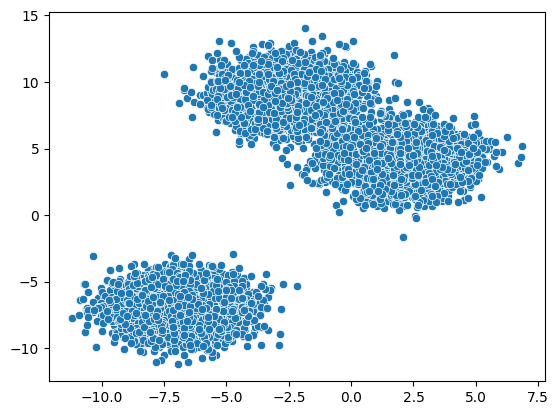

In [6]:
# Visualize Plot
sns.scatterplot(x=X[:,0],y=X[:,1])

In [8]:
# Apply Kmean Clustering 
from sklearn.cluster import KMeans

kmean = KMeans(
     n_clusters=3,
     random_state=42
)
labels = kmean.fit_predict(X)

<Axes: >

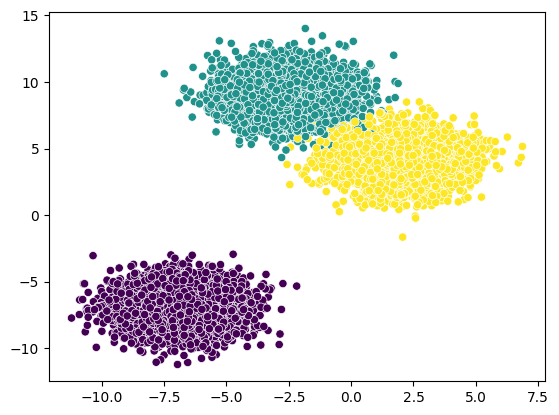

In [11]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

- ***Choosing K value***
    - Elbow Method
    - Silhoutte Score

In [ ]:
# Elbow Method 
wcss = []
for k in range(1,16):
     kmean = KMeans(n_clusters=k)
     kmean.fit_predict(X)
     wcss.append(kmean.inertia_)

<Axes: >

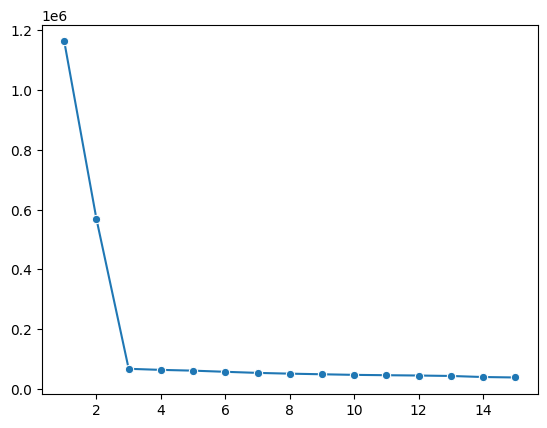

In [14]:
sns.lineplot(x=range(1,16),y=wcss,marker='o')

- ***Kneed Module (automatically find value of K for making clusters)***

In [16]:
from kneed import KneeLocator
knee = KneeLocator(range(1,16),wcss,curve="convex",direction="decreasing")
print(f"Optimal K={knee.elbow}")

Optimal K=3


In [17]:
# Silhouette Score (evaluation metrics)
from sklearn.metrics import silhouette_score
ss = []

for k in range(2,17):
     kmean = KMeans(n_clusters=k)
     labels = kmean.fit_predict(X)
     score = silhouette_score(X,labels)
     ss.append(score)

<Axes: >

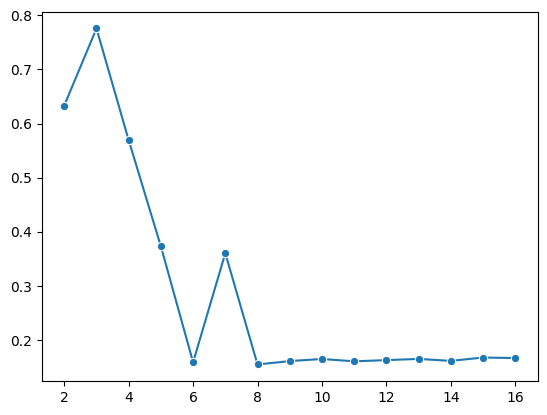

In [18]:
# Plot K & ss
sns.lineplot(x=range(2,17),y=ss,marker='o')

### ***K-Mean Clustering On Iris Dataset***

In [20]:
import seaborn as sns  
import pandas as pd 
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

df = load_iris(as_frame=True).frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [22]:
X = df.drop("target",axis=1)
y = df["target"]

In [24]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>

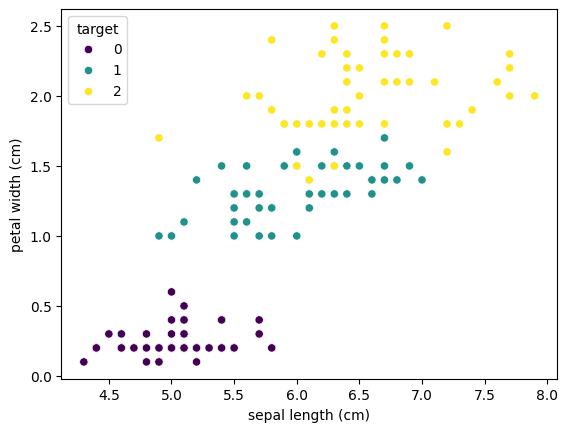

In [28]:
# Visualize
sns.scatterplot(
    x=X.iloc[:, 0],
    y=X.iloc[:, 3],
    hue=y,
    palette="viridis"
)

In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

In [32]:
# Elbow Method
wcss = []
for k in range(1,11):
     kmeans = KMeans(n_clusters=k)
     kmeans.fit(X)
     wcss.append(kmeans.inertia_)

In [33]:
print(kmean.inertia_)

37534.161852594116


In [34]:
from kneed import KneeLocator
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
print(f"Optimal K={knee.elbow}")


Optimal K=3


<Axes: >

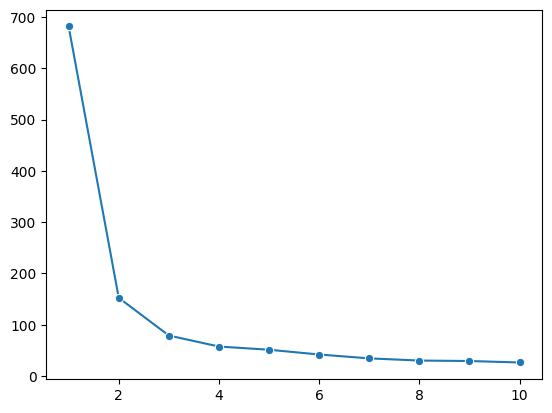

In [35]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

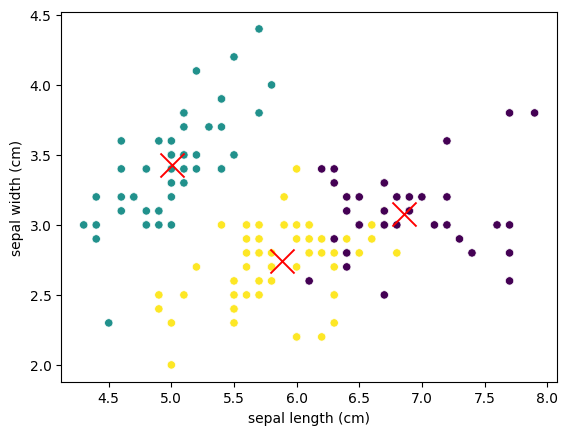

In [37]:
# KMeans Clustering
kmeans = KMeans(n_clusters=3,random_state=42)
labels = kmeans.fit_predict(X)
sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="x",c="red",s=300)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

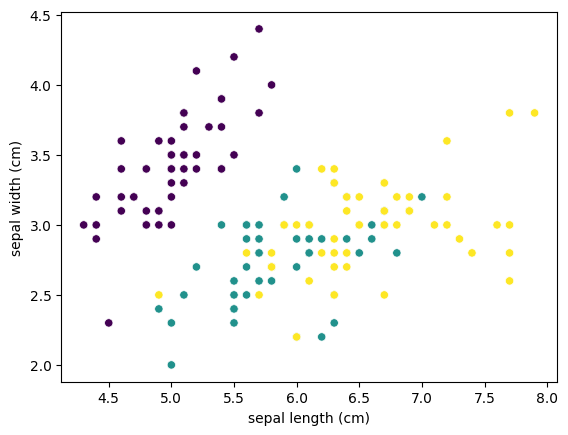

In [38]:
sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,1],c=y)

In [41]:
import seaborn as sns 
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

df = load_iris(as_frame=True).frame 

X = df.drop("target",axis=1)
y = df["target"]

# Scaling 
scale = StandardScaler()
x_scaled = scale.fit_transform(X)

<Axes: >

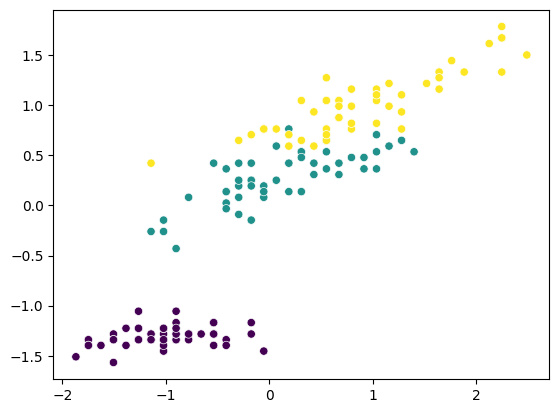

In [43]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=y)

Text(0.5, 1.0, 'Dendogram for hierarchical Clustering')

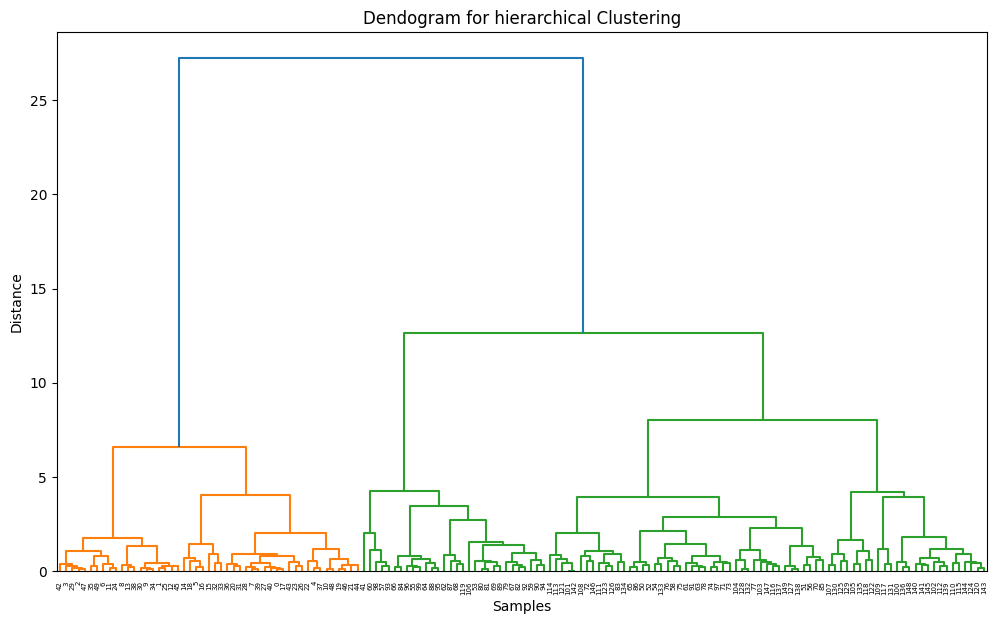

In [44]:
from scipy.cluster.hierarchy import linkage,dendrogram
import matplotlib.pyplot as plt 

# Linkage 
z = linkage(x_scaled,method="ward")

plt.figure(figsize=(12,7))
dendrogram(z)
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title("Dendogram for hierarchical Clustering")

In [45]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(x_scaled)

<Axes: >

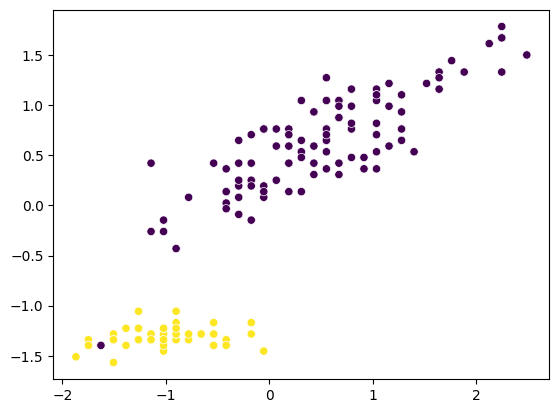

In [46]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)

In [47]:
# DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
     eps=0.8,
     min_samples=5
)
labels = dbscan.fit_predict(x_scaled)

<Axes: >

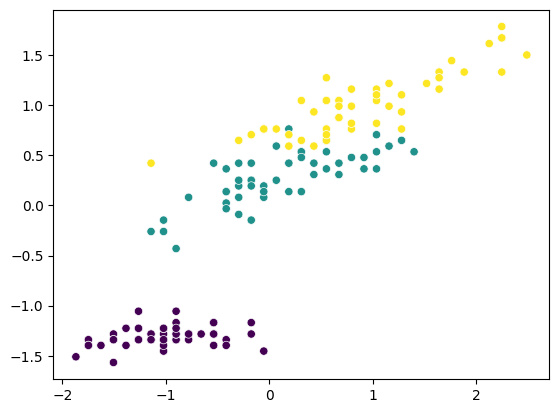

In [48]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=y)